### Understand the problem 

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


### Data Exploration

In [2]:
dataset_train=pd.read_csv("/kaggle/input/mobile-price-classification/train.csv")
dataset_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
dataset_test=pd.read_csv("/kaggle/input/mobile-price-classification/test.csv")
dataset_test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [4]:
dataset_train.shape

(2000, 21)

In [5]:
dataset_test.shape

(1000, 21)

In [6]:
dataset_train.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
dataset_test.isnull().sum()

id               0
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64

In [8]:
for i in dataset_train:
    print(i,":",len(dataset_train[i].unique()))

battery_power : 1094
blue : 2
clock_speed : 26
dual_sim : 2
fc : 20
four_g : 2
int_memory : 63
m_dep : 10
mobile_wt : 121
n_cores : 8
pc : 21
px_height : 1137
px_width : 1109
ram : 1562
sc_h : 15
sc_w : 19
talk_time : 19
three_g : 2
touch_screen : 2
wifi : 2
price_range : 4


In [9]:
for i in dataset_test:
    print(i,":",len(dataset_test[i].unique()))

id : 1000
battery_power : 721
blue : 2
clock_speed : 26
dual_sim : 2
fc : 20
four_g : 2
int_memory : 63
m_dep : 10
mobile_wt : 121
n_cores : 8
pc : 21
px_height : 694
px_width : 743
ram : 872
sc_h : 15
sc_w : 19
talk_time : 19
three_g : 2
touch_screen : 2
wifi : 2


### Outliers Removal

In [10]:
dataset_train.mean()

battery_power    1238.51850
blue                0.49500
clock_speed         1.52225
dual_sim            0.50950
fc                  4.30950
four_g              0.52150
int_memory         32.04650
m_dep               0.50175
mobile_wt         140.24900
n_cores             4.52050
pc                  9.91650
px_height         645.10800
px_width         1251.51550
ram              2124.21300
sc_h               12.30650
sc_w                5.76700
talk_time          11.01100
three_g             0.76150
touch_screen        0.50300
wifi                0.50700
price_range         1.50000
dtype: float64

In [11]:
z_scores = np.abs((dataset_train - np.mean(dataset_train)) / np.std(dataset_train))

In [12]:
threshold = 3


In [13]:
outliers = dataset_train[z_scores > threshold]


In [14]:
clean_data = dataset_train[z_scores <= threshold]

In [15]:
clean_data.mean()

battery_power    1238.518500
blue                0.495000
clock_speed         1.522250
dual_sim            0.509500
fc                  4.226358
four_g              0.521500
int_memory         32.046500
m_dep               0.501750
mobile_wt         140.249000
n_cores             4.520500
pc                  9.916500
px_height         645.108000
px_width         1251.515500
ram              2124.213000
sc_h               12.306500
sc_w                5.767000
talk_time          11.011000
three_g             0.761500
touch_screen        0.503000
wifi                0.507000
price_range         1.500000
dtype: float64

### Split the data

In [16]:
x=dataset_train[['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi']]
y=dataset_train[['price_range']]

In [17]:
x

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,14,1222,1890,668,13,4,19,1,1,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,3,915,1965,2032,11,10,16,1,1,1
1997,1911,0,0.9,1,1,1,36,0.7,108,8,3,868,1632,3057,9,1,5,1,1,0
1998,1512,0,0.9,0,4,1,46,0.1,145,5,5,336,670,869,18,10,19,1,1,1


In [18]:
y

,price_range
0,1
1,2
2,2
3,2
4,1
...,...
1995,0
1996,2
1997,3
1998,0


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=10,random_state=30)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled = scaler.fit_transform(dataset_train)


x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled=scaler.transform(x_test)
print("Mean value:",x_train_scaled.mean(axis=0))
print("SD value:",x_train_scaled.std(axis=0))

Mean value: [ 1.73172476e-16 -1.42822660e-17 -8.56935963e-17  6.78407637e-17
  1.42822660e-17 -6.78407637e-17  5.35584977e-18 -1.96381158e-16
  1.10687562e-16 -1.07116995e-16 -9.90832207e-17 -1.07116995e-17
 -3.57056651e-18 -1.10687562e-16 -1.94149554e-16  4.37394398e-17
 -3.57056651e-18 -4.99879312e-17  9.46200126e-17  1.42822660e-17]
SD value: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Select the Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
model = RandomForestRegressor(n_estimators = 100, random_state = 0)

In [23]:
model.fit(x_train_scaled, y_train) 

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """Entry point for launching an IPython kernel.


RandomForestRegressor(random_state=0)

In [24]:
model.score(x_test_scaled,y_test)*100 #accuracy

90.83275862068966

In [25]:
predict = model.predict(x_test_scaled)  # test the output by changing values
predict

array([2.93, 0.08, 0.91, 1.04, 1.72, 0.74, 2.96, 3.  , 2.08, 0.78])

In [26]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
error = mean_absolute_error(predict,y_test)*100
error#error

20.0

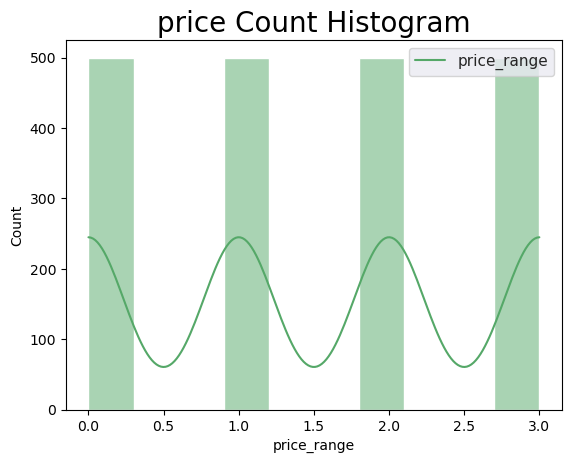

In [27]:
#set figure
f, ax = plt.subplots(1,1)

#graph histogram
sns.set(style='darkgrid')
sns.histplot(data = dataset_train, x = "price_range", color='g', bins=10, kde = True, legend=False)

#Set title
ax.set_title("price Count Histogram",  fontsize=20)
# plt.ylim(0, 100)
#set legend
plt.legend(loc='upper right', labels=['price_range'])

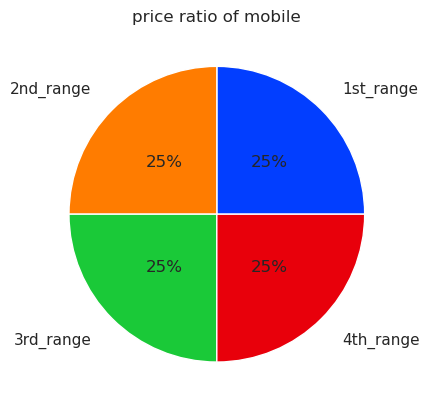

In [28]:
a = dataset_train['price_range'].value_counts()
labels = ['1st_range', '2nd_range','3rd_range','4th_range']
plt.title("price ratio of mobile")
palette_color = sns.color_palette('bright')

plt.pie(a,
        labels=labels,
        colors = palette_color,
        autopct='%1.0f%%', #autopct is used for display percentage of value
        pctdistance=0.5, #pctdistance is used for set distance of percentage from center
        labeldistance=1.2) #labeldistance is used for set distance of label from center


plt.show() 